In [1]:
from qiskit.quantum_info import SparsePauliOp, Pauli, Statevector 
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation
import numpy as np 
A = np.array([[ 1.5 , -0.25,  0.  ,  0.  ],
       [-0.25,  1.5 , -0.25,  0.  ],
       [ 0.  , -0.25,  1.5 , -0.25],
       [ 0.  ,  0.  , -0.25,  1.5 ]])
pauli_op = SparsePauliOp.from_operator(A)
pauli_op

SparsePauliOp(['II', 'IX', 'XX', 'YY'],
              coeffs=[ 1.5  +0.j, -0.25 +0.j, -0.125+0.j, -0.125+0.j])

In [2]:
# convert |0>^k -----> Sum( c_i|i>) 
# U∣0⟩=k∑​ak​∣k⟩
n_ancilla = int(np.ceil(np.log2(len(pauli_op.coeffs))))
n_reg = A.size
amps = np.array(pauli_op.coeffs)
amps = np.sqrt(amps / np.linalg.norm(amps,ord=1))
prep_gate = StatePreparation(amps,label="Prep")


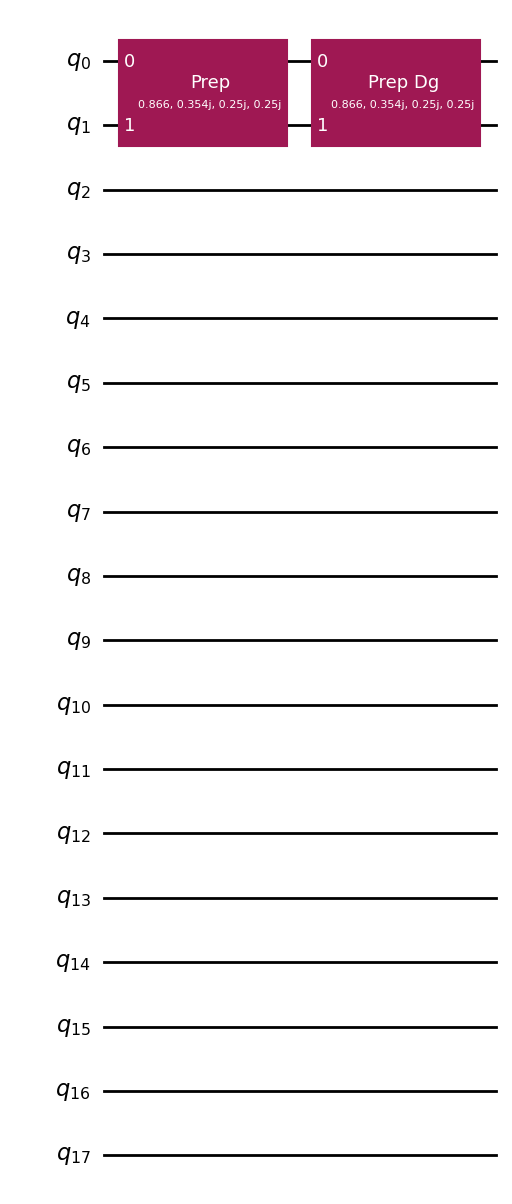

In [ ]:
qc  = QuantumCircuit(n_ancilla + n_reg)
qc.append(prep_gate,qc.qubits[:n_ancilla])

qc.append(prep_gate.inverse(),qc.qubits[:n_ancilla])
qc.draw("mpl")


In [ ]:
def selection_matrix(pauli_op : SparsePauliOp):
    dim = len[pauli_op.coeffs]
    select_matrix = None
    for i in range(dim):
        u_k = pauli_op.paulis[i].to_matrix()
        ket_i = Statevector.from_int(i, dim).data
        outer_product = np.outer(ket_i,ket_i.conj())

        if not select_matrix:
            select_matrix = np.kron(outer_product,u_k)
        else:
            select_matrix = select_matrix + np.kron(outer_product,u_k)
    return select_matrix
